# Transaction Anomaly Detection

This notebook trains an Isolation Forest model to detect anomalous transactions. 
We will generate synthetic transaction data that mimics the structure of the Smart Personal Finance app, engineer relevant behavioral and temporal features, train the model, and export it for use in the backend API.

In [47]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Data Generation

We generate synthetic transactions with typical categories, amounts, and dates. We will also inject some clear anomalies (e.g., extremely large amounts, unusual times).

In [48]:
# Load the real-world Kaggle personal finance dataset
# The dataset contains dirty amounts (mixed with currency symbols) and messy dates
df = pd.read_csv('data/budgetwise_finance_dataset.csv')
print(f"Loaded {len(df)} raw transactions.")

# 1. Clean the 'amount' column
# Remove any non-numeric characters (like Rs, $, commas, spaces) except the decimal point
df['amount'] = df['amount'].astype(str).str.replace(r'[^\d\.]', '', regex=True)
# Convert to numeric, dropping rows where the amount is entirely missing/unparseable
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df.dropna(subset=['amount']).copy()

# 2. Clean and standardized the 'date' column
# Try parsing multiple formats and coercing failures to NaT (Not a Time)
df['datetime'] = pd.to_datetime(df['date'], errors='coerce')
# Drop rows where the date couldn't be parsed
df = df.dropna(subset=['datetime']).copy()

# Sort chronologically to prepare for feature engineering (like time differences)
df = df.sort_values('datetime').reset_index(drop=True)

# Rename transaction_type to type for compatibility with the rest of the pipeline
if 'transaction_type' in df.columns:
    df = df.rename(columns={'transaction_type': 'type'})

# Define our own temporary 'is_anomaly' column to train on.
# Since this dataset doesn't have true anomaly labels, 
# we will flag the top 5% of highest transactions as anomalies for training purposes.
threshold = df['amount'].quantile(0.95)
df['is_anomaly'] = (df['amount'] > threshold).astype(int)

print(f"Cleaned dataset contains {len(df)} transactions.")
df.head()

Loaded 15900 raw transactions.
Cleaned dataset contains 5966 transactions.


,transaction_id,user_id,date,type,category,amount,payment_mode,location,notes,datetime,is_anomaly
0,T0565,U052,2021-01-01,Income,Freelance,76296.0,Csh,BAN,Internet bill,2021-01-01,1
1,T2971,U138,2021-01-01,Expense,Rnt,1575.0,bank transfer,LUC,Doctor consultation,2021-01-01,0
2,T12231,U123,2021-01-01,Expense,Food,3346.0,bank transfer,Mumbai,Doctor consultation,2021-01-01,0
3,T12231,U123,2021-01-01,Expense,Food,3346.0,bank transfer,Mumbai,Doctor consultation,2021-01-01,0
4,T2465,U098,2021-01-01,Expense,Rent,12502.0,cash,BANGALORE,!!!,2021-01-01,0


## 2. Feature Engineering

To help the model understand behavior, we extract features from timestamps and historical averages.

In [50]:
# Function to engineer features from the cleaned dataset
def extract_features(df):
    df = df.copy()
    
    # Temporal features: Extract day of week from the standardized datetime
    df['day_of_week'] = df['datetime'].dt.dayofweek
    # Create a binary feature for weekends (Saturday=5, Sunday=6)
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Calculate historical category averages using an expanding mean up to that point
    # It helps the model see if a new transaction is unusually high for that specific category
    df['cat_avg_amount'] = df.groupby('category')['amount'].transform(lambda x: x.expanding().mean())
    # Fill NaN for first occurrences with the amount itself
    df['cat_avg_amount'] = df['cat_avg_amount'].fillna(df['amount'])
    
    # Ratio of this transaction amount to the historical average for this category
    df['amount_vs_avg'] = df['amount'] / (df['cat_avg_amount'] + 1)
    
    # Time since last transaction (in days, since the dataset doesn't have timestamps)
    df['time_diff_days'] = df['datetime'].diff().dt.total_seconds() / (3600.0 * 24)
    df['time_diff_days'] = df['time_diff_days'].fillna(0)
    
    return df

# Apply feature engineering
df_feat = extract_features(df)
df_feat.head()

,transaction_id,user_id,date,type,category,amount,payment_mode,location,notes,datetime,is_anomaly,day_of_week,is_weekend,cat_avg_amount,amount_vs_avg,time_diff_days
0,T0565,U052,2021-01-01,Income,Freelance,76296.0,Csh,BAN,Internet bill,2021-01-01,1,4,0,76296.0,0.999987,0.0
1,T2971,U138,2021-01-01,Expense,Rnt,1575.0,bank transfer,LUC,Doctor consultation,2021-01-01,0,4,0,1575.0,0.999365,0.0
2,T12231,U123,2021-01-01,Expense,Food,3346.0,bank transfer,Mumbai,Doctor consultation,2021-01-01,0,4,0,3346.0,0.999701,0.0
3,T12231,U123,2021-01-01,Expense,Food,3346.0,bank transfer,Mumbai,Doctor consultation,2021-01-01,0,4,0,3346.0,0.999701,0.0
4,T2465,U098,2021-01-01,Expense,Rent,12502.0,cash,BANGALORE,!!!,2021-01-01,0,4,0,12502.0,0.999920,0.0


## 3. Preprocessing Pipeline

We will build a pipeline that includes standard scaling and specific feature selection.

In [51]:
# Import machine learning pipeline components and Isolation Forest
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

# Define numerical features (swapped hour for time_diff_days)
numeric_features = ['amount', 'amount_vs_avg', 'time_diff_days']
# Define categorical features
categorical_features = ['category', 'type', 'is_weekend']

# Preprocessing for numerical data: impute missing values with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: impute missing with a constant, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the main ML pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(contamination=0.05, random_state=42, n_estimators=100))
])


## 4. Model Training & Evaluation

In [52]:
# Train the model using the engineered features
model_pipeline.fit(df_feat)

# Predict anomalies: -1 for anomaly, 1 for normal
predictions = model_pipeline.predict(df_feat)
df_feat['pred_anomaly'] = [1 if p == -1 else 0 for p in predictions]

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(df_feat['is_anomaly'], df_feat['pred_anomaly']))

print("\nClassification Report:")
print(classification_report(df_feat['is_anomaly'], df_feat['pred_anomaly']))

Confusion Matrix:
[[5509  158]
 [ 158  141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5667
           1       0.47      0.47      0.47       299

    accuracy                           0.95      5966
   macro avg       0.72      0.72      0.72      5966
weighted avg       0.95      0.95      0.95      5966



## 5. Visualization

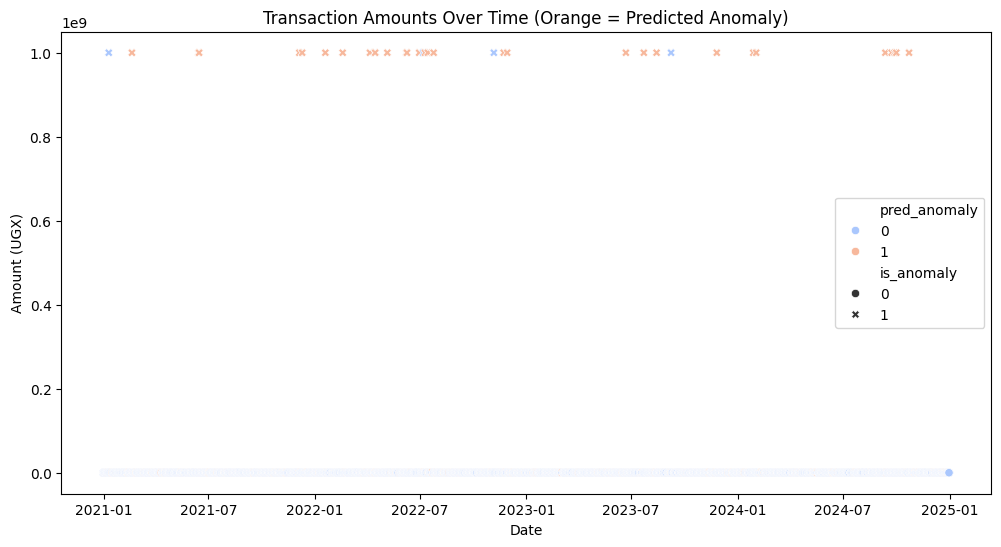

In [53]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_feat, x='datetime', y='amount', hue='pred_anomaly', style='is_anomaly', palette='coolwarm')
plt.title('Transaction Amounts Over Time (Orange = Predicted Anomaly)')
plt.ylabel('Amount (UGX)')
plt.xlabel('Date')
plt.show()

## 6. Export the Pipeline for the Backend API

For the backend to use this without manual feature engineering of historical averages, we should package a function or script, but for now we export the main preprocessor and isolation forest pipeline.

In [7]:
import os

model_dir = '../backend/training/models/anomaly_detector'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'anomaly_iforest_pipeline.pkl')
joblib.dump(model_pipeline, model_path)
print(f"Model exported successfully to {model_path}")

Model exported successfully to ../backend/training/models/anomaly_detector/anomaly_iforest_pipeline.pkl


## 7. Inference Example

How to use this model to make predictions given user behavioral context.

In [10]:
# Example of testing inference using the Kaggle dataset's schema
new_tx = pd.DataFrame([{
    'amount': 5000000,     # Very high amount
    'amount_vs_avg': 80.0, # 80x the usual spending for this category
    'time_diff_days': 0.1, # Short time difference
    'category': 'Rent',
    'type': 'Expense',
    'is_weekend': 0
}])

# Feed the sample into the trained pipeline
pred = model_pipeline.predict(new_tx)

# The model outputs -1 meaning 'anomaly' and 1 meaning 'normal'
print("Anomaly (-1) or Normal (1)?", pred[0])


Anomaly (-1) or Normal (1)? -1
